In [1]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import MultipleLocator


In [2]:
def get_regret(modelname, prefix, prob="knapsack-gen-ood"):
    return np.load(f"/home/genghaoyu/OR/PTO/Rethink1.0/saved_records/{prob}/{modelname}/{prefix}/results.npy")[1]
mse_result = get_regret("mse", "new-OOD-30-EERM-3-0.5-5e-2")


In [3]:
mse_result.mean(), np.std(mse_result)

(13.655, 6.77834603719816)

In [4]:
mse_names = ['new-OOD-30-EERM-1-4.0-5e-3', 'new-OOD-30-EERM-3-4.0-5e-3', 'new-OOD-30-EERM-3-4.0-5e-3', 'new-OOD-30-EERM-3-4.0-5e-3', 'new-OOD-30-EERM-5-4.0-1e-2']
spo_names = ['new-OOD-30-EERM-1-4.0-5e-3', 'new-OOD-30-EERM-3-4.0-5e-3', 'new-OOD-30-EERM-3-4.0-5e-3', 'new-OOD-30-EERM-3-4.0-5e-3', 'new-OOD-30-EERM-5-4.0-1e-2']
mse_results = [get_regret("mse", name) for name in mse_names]
spo_results = [get_regret("spo", name) for name in spo_names]

## knapsack figs

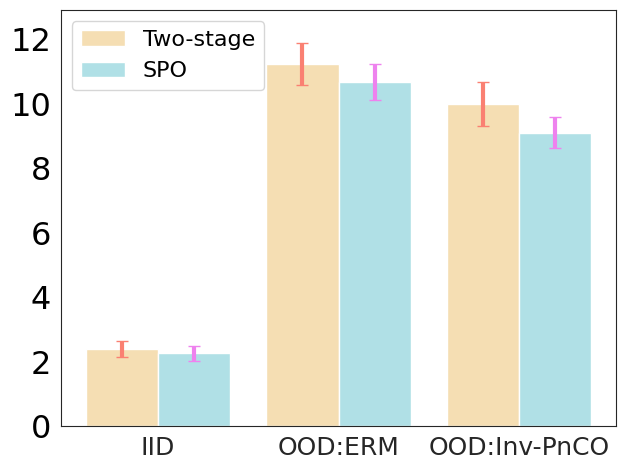

In [6]:
import matplotlib.pyplot as plt
import numpy as np
sns.set_style("white")
mse_names = \
    ["new-IID-30", "new-OOD-ERM-30", "new-OOD-30-EERM-5-4.0-1e-2"]
spo_names = \
    ["new-IID-30", "new-OOD-ERM-30", "new-OOD-30-EERM-1-1.0-5e-2"]

mse_results = [get_regret("mse", name) for name in mse_names]
spo_results = [get_regret("spo", name) for name in spo_names]

x=np.arange(3)
#数据集
y1 = [res.mean() for res in mse_results]
y2 = [res.mean() for res in spo_results]
#误差列表
std_err1= np.array([ np.std(res) for res in mse_results])/10
std_err2=  np.array([ np.std(res) for res in spo_results])/10
tick_label=["IID", "OOD:ERM", "OOD:Inv-PnCO"]
 
error_params1=dict(elinewidth=3,ecolor='salmon',capsize=4)#设置误差标记参数
error_params2=dict(elinewidth=3,ecolor='violet',capsize=4)#设置误差标记参数
#设置柱状图宽度
bar_width=0.4
#绘制柱状图，设置误差标记以及柱状图标签
plt.bar(x,y1,bar_width,color=['wheat']*len(x),yerr=std_err1,error_kw=error_params1,label='Two-stage')
plt.bar(x+bar_width,y2,bar_width,color=['powderblue']*len(x),yerr=std_err2,error_kw=error_params2,label='SPO')

plt.style.use('default')
plt.xticks(x+bar_width/2, tick_label, fontsize=18)#设置x轴的标签
plt.yticks(fontsize=23,color='#000000')
plt.ylim(0,12.9)
#设置网格
# plt.grid(True,axis='y',ls=':',color='r',alpha=0.3)
#显示图例
plt.legend(fontsize=16, loc="upper left", ncol=1)
#显示图形
plt.tight_layout()
plt.savefig("/home/genghaoyu/OR/PTO/Rethink1.0/visual/figs/ood_figs/fig_kp30.pdf")
plt.show()


### sensi on n envs

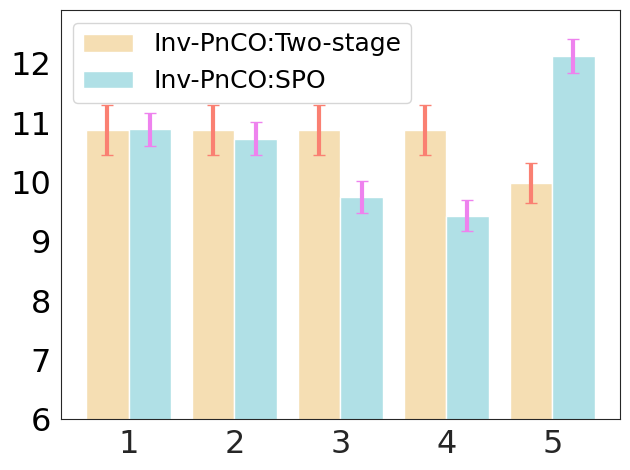

In [18]:
import matplotlib.pyplot as plt
import numpy as np
sns.set_style("white")

mse_names = \
    ['new-OOD-30-EERM-1-4.0-5e-3', 'new-OOD-30-EERM-2-4.0-5e-3', 'new-OOD-30-EERM-3-4.0-5e-3', 'new-OOD-30-EERM-4-4.0-5e-3', 'new-OOD-30-EERM-5-4.0-1e-2']

spo_names = \
    ['new-OOD-30-EERM-1-4.0-5e-3', 'new-OOD-30-EERM-2-4.0-1e-2', 'new-OOD-30-EERM-3-4.0-5e-3', 'new-OOD-30-EERM-4-4.0-5e-3', 'new-OOD-30-EERM-5-4.0-1e-2']


mse_results = [get_regret("mse", name) for name in mse_names]
spo_results = [get_regret("spo", name) for name in spo_names]

x=np.arange(5)
#数据集
y1 = [res.mean() for res in mse_results]
y2 = [res.mean() for res in spo_results]
#误差列表
std_err1= np.array([ np.std(res) for res in mse_results])/20
std_err2=  np.array([ np.std(res) for res in spo_results])/20
tick_label=np.arange(1,6)
 
error_params1=dict(elinewidth=3,ecolor='salmon',capsize=4)#设置误差标记参数
error_params2=dict(elinewidth=3,ecolor='violet',capsize=4)#设置误差标记参数
#设置柱状图宽度
bar_width=0.4
#绘制柱状图，设置误差标记以及柱状图标签
plt.bar(x,y1,bar_width,color=['wheat']*len(x),yerr=std_err1,error_kw=error_params1,label='Inv-PnCO:Two-stage')
plt.bar(x+bar_width,y2,bar_width,color=['powderblue']*len(x),yerr=std_err2,error_kw=error_params2,label='Inv-PnCO:SPO')

plt.style.use('default')
plt.xticks(x+bar_width/2, tick_label, fontsize=23)#设置x轴的标签
plt.yticks(fontsize=23,color='#000000')
plt.ylim(6,12.9)
#设置网格
# plt.grid(True,axis='y',ls=':',color='r',alpha=0.3)
#显示图例
plt.legend(fontsize=18, loc="upper left", ncol=1)
#显示图形
plt.tight_layout()
plt.savefig("/home/genghaoyu/OR/PTO/Rethink1.0/visual/figs/ood_sensi/sensi_envs.pdf")
plt.show()


### sensi on beta

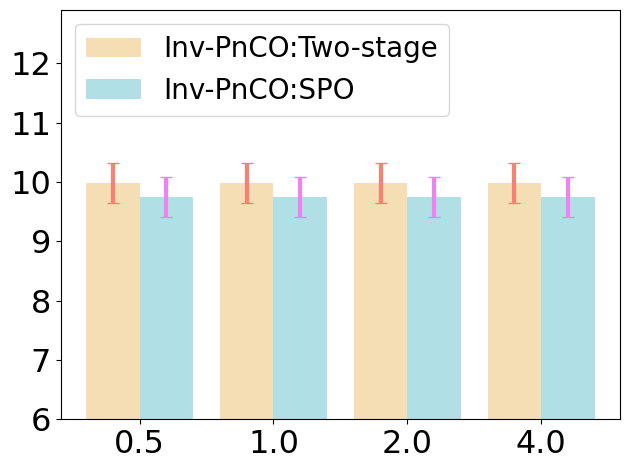

In [14]:
import matplotlib.pyplot as plt
import numpy as np

mse_names = \
    ['new-OOD-30-EERM-5-0.5-1e-2', 'new-OOD-30-EERM-5-1.0-1e-2', 'new-OOD-30-EERM-5-2.0-1e-2', 'new-OOD-30-EERM-5-4.0-1e-2']

spo_names = \
    ['new-OOD-30-EERM-3-0.5-5e-3', 'new-OOD-30-EERM-3-1.0-5e-3', 'new-OOD-30-EERM-3-2.0-5e-3', 'new-OOD-30-EERM-3-4.0-5e-3']

mse_results = [get_regret("mse", name) for name in mse_names]
spo_results = [get_regret("spo", name) for name in spo_names]

x= np.arange(4)
#数据集
y1 = [res.mean() for res in mse_results]
y2 = [res.mean() for res in spo_results]
#误差列表
std_err1= np.array([ np.std(res) for res in mse_results])/20
std_err2=  np.array([ np.std(res) for res in spo_results])/20
tick_label=["0.5","1.0","2.0","4.0"]
 
error_params1=dict(elinewidth=3,ecolor='salmon',capsize=4)#设置误差标记参数
error_params2=dict(elinewidth=3,ecolor='violet',capsize=4)#设置误差标记参数
#设置柱状图宽度
bar_width=0.4
#绘制柱状图，设置误差标记以及柱状图标签
plt.bar(x,y1,bar_width,color=['wheat']*len(x),yerr=std_err1,error_kw=error_params1,label='Inv-PnCO:Two-stage')
plt.bar(x+bar_width,y2,bar_width,color=['powderblue']*len(x),yerr=std_err1,error_kw=error_params2,label='Inv-PnCO:SPO')

plt.style.use('default')
plt.xticks(x+bar_width/2, tick_label, fontsize=23)#设置x轴的标签
plt.yticks(fontsize=23,color='#000000')
plt.ylim(6,12.9)
#设置网格
# plt.grid(True,axis='y',ls=':',color='r',alpha=0.3)
#显示图例
plt.legend(fontsize=20, loc="upper left", ncol=1)
#显示图形
plt.tight_layout()
plt.savefig("/home/genghaoyu/OR/PTO/Rethink1.0/visual/figs/ood_sensi/sensi_beta.pdf")
plt.show()


### cap

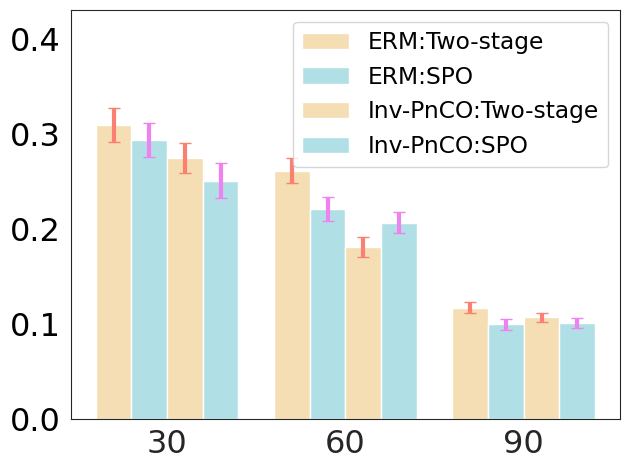

In [8]:
import matplotlib.pyplot as plt
import numpy as np
sns.set_style("white")

erm_mse_names = \
   ["new-OOD-ERM-30", "new-OOD-ERM-60", "new-OOD-ERM-90"]

erm_spo_names = \
    ["new-OOD-ERM-30", "new-OOD-ERM-60", "new-OOD-ERM-90"]

ipo_mse_names = \
    ["new-OOD-30-EERM-5-4.0-1e-2", "new-OOD-60-EERM-5-4.0-1e-2", "new-OOD-90-EERM-5-4.0-5e-2"]

ipo_spo_names = \
    ["new-OOD-30-EERM-1-0.5-5e-2", "new-OOD-60-EERM-5-4.0-5e-2", "new-OOD-90-EERM-5-4.0-5e-2"]

erm_mse_results = [get_regret("mse", name) for name in erm_mse_names]
erm_spo_results = [get_regret("spo", name) for name in erm_spo_names]
ipo_mse_results = [get_regret("mse", name) for name in ipo_mse_names]
ipo_spo_results = [get_regret("spo", name) for name in ipo_spo_names]


optimal_res = np.array([36.315, 56.935, 70.235])

x= np.arange(3)
#数据集
y1 = np.array( [res.mean() for res in erm_mse_results]) / optimal_res
y2 = np.array( [res.mean() for res in erm_spo_results]) / optimal_res
y3 = np.array( [res.mean() for res in ipo_mse_results]) / optimal_res
y4 = np.array( [res.mean() for res in ipo_spo_results]) / optimal_res

#误差列表
std_err1= np.array([ np.std(res) for res in erm_mse_results])/10 / optimal_res
std_err2=  np.array([ np.std(res) for res in erm_spo_results])/10 / optimal_res
std_err3=  np.array([ np.std(res) for res in ipo_mse_results])/10  / optimal_res
std_err4=  np.array([ np.std(res) for res in ipo_spo_results])/10  / optimal_res

tick_label=["30", "60", "90"]
 
error_params1=dict(elinewidth=3,ecolor='salmon',capsize=4)#设置误差标记参数
error_params2=dict(elinewidth=3,ecolor='violet',capsize=4)#设置误差标记参数
error_params3=dict(elinewidth=3,ecolor='salmon',capsize=4)#设置误差标记参数
error_params4=dict(elinewidth=3,ecolor='violet',capsize=4)#设置误差标记参数
#设置柱状图宽度
bar_width=0.2
#绘制柱状图，设置误差标记以及柱状图标签
plt.bar(x,y1,bar_width,color=['wheat']*len(x),yerr=std_err1,error_kw=error_params1,label='ERM:Two-stage')
plt.bar(x+bar_width,y2,bar_width,color=['powderblue']*len(x),yerr=std_err1,error_kw=error_params2,label='ERM:SPO')
plt.bar(x+bar_width*2,y3,bar_width,color=['wheat']*len(x),yerr=std_err2,error_kw=error_params3,label='Inv-PnCO:Two-stage')
plt.bar(x+bar_width*3,y4,bar_width,color=['powderblue']*len(x),yerr=std_err3,error_kw=error_params4,label='Inv-PnCO:SPO')


plt.style.use('default')
plt.xticks(x+bar_width*1.5, tick_label, fontsize=23)#设置x轴的标签
plt.yticks(fontsize=23,color='#000000')
# plt.ylim(6,15.7)
plt.ylim(0,0.43)

ax=plt.gca()
y_major_locator=MultipleLocator(0.1)
#把y轴的刻度间隔设置为10，并存在变量里
ax.yaxis.set_major_locator(y_major_locator)
#把y轴的主刻度设置为10的倍数

#设置网格
# plt.grid(True,axis='y',ls=':',color='r',alpha=0.3)
#显示图例
plt.legend(fontsize=16.8, loc="upper right", ncol=1)
#显示图形
plt.tight_layout()
plt.savefig("/home/genghaoyu/OR/PTO/Rethink1.0/visual/figs/ood_sensi/sensi_cap.pdf")
plt.show()


### size

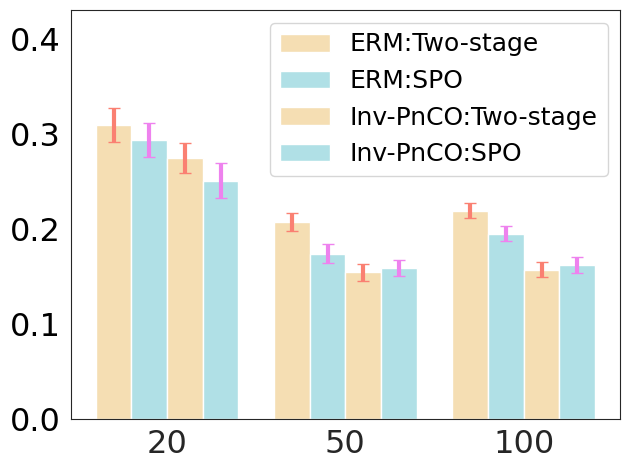

In [12]:
import matplotlib.pyplot as plt
import numpy as np
sns.set_style("white")
erm_mse_names = \
    ["new-OOD-ERM-30", "new-OOD-ERM-size50", "new-OOD-ERM-size100"]

erm_spo_names = \
    ["new-OOD-ERM-30",  "new-OOD-ERM-size50", "new-OOD-ERM-size100"]

ipo_mse_names = \
    ["new-OOD-30-EERM-5-4.0-1e-2", "new-OOD-size50-EERM-5-4.0-5e-3", "new-OOD-size100-EERM-5-4.0-1e-3"]

ipo_spo_names = \
    ["new-OOD-30-EERM-1-0.5-5e-2", "new-OOD-size50-EERM-3-4.0-1e-3", "new-OOD-size100-EERM-3-4.0-5e-3"]

erm_mse_results = [get_regret("mse", name) for name in erm_mse_names]
erm_spo_results = [get_regret("spo", name) for name in erm_spo_names]
ipo_mse_results = [get_regret("mse", name) for name in ipo_mse_names]
ipo_spo_results = [get_regret("spo", name) for name in ipo_spo_names]

optimal_res = np.array([36.315, 163.55, 308.685])

x= np.arange(3)
#数据集
y1 = np.array([res.mean() for res in erm_mse_results]) / optimal_res
y2 = np.array([res.mean() for res in erm_spo_results]) / optimal_res
y3 = np.array([res.mean() for res in ipo_mse_results]) / optimal_res
y4 = np.array([res.mean() for res in ipo_spo_results]) / optimal_res

#误差列表
std_err1= np.array([ np.std(res) for res in erm_mse_results])/10 / optimal_res
std_err2=  np.array([ np.std(res) for res in erm_spo_results])/10 / optimal_res
std_err3=  np.array([ np.std(res) for res in ipo_mse_results])/10  / optimal_res
std_err4=  np.array([ np.std(res) for res in ipo_spo_results])/10  / optimal_res

tick_label=["20", "50", "100"]
 
error_params1=dict(elinewidth=3,ecolor='salmon',capsize=4)#设置误差标记参数
error_params2=dict(elinewidth=3,ecolor='violet',capsize=4)#设置误差标记参数
error_params3=dict(elinewidth=3,ecolor='salmon',capsize=4)#设置误差标记参数
error_params4=dict(elinewidth=3,ecolor='violet',capsize=4)#设置误差标记参数
#设置柱状图宽度
bar_width=0.2
#绘制柱状图，设置误差标记以及柱状图标签
plt.bar(x,y1,bar_width,color=['wheat']*len(x),yerr=std_err1,error_kw=error_params1,label='ERM:Two-stage')
plt.bar(x+bar_width,y2,bar_width,color=['powderblue']*len(x),yerr=std_err1,error_kw=error_params2,label='ERM:SPO')
plt.bar(x+bar_width*2,y3,bar_width,color=['wheat']*len(x),yerr=std_err2,error_kw=error_params3,label='Inv-PnCO:Two-stage')
plt.bar(x+bar_width*3,y4,bar_width,color=['powderblue']*len(x),yerr=std_err3,error_kw=error_params4,label='Inv-PnCO:SPO')


plt.style.use('default')
plt.xticks(x+bar_width*1.5, tick_label, fontsize=23)#设置x轴的标签
plt.yticks(fontsize=23,color='#000000')
# plt.ylim(0,0.99)
plt.ylim(0,0.43)

ax=plt.gca()
y_major_locator=MultipleLocator(0.1)
#把y轴的刻度间隔设置为10，并存在变量里
ax.yaxis.set_major_locator(y_major_locator)
#把y轴的主刻度设置为10的倍数

#设置网格
# plt.grid(True,axis='y',ls=':',color='r',alpha=0.3)
#显示图例
plt.legend(fontsize=18, loc="upper right",ncol=1)
#显示图形
plt.tight_layout()
plt.savefig("/home/genghaoyu/OR/PTO/Rethink1.0/visual/figs/ood_sensi/sensi_size.pdf")
plt.show()


## SP figs

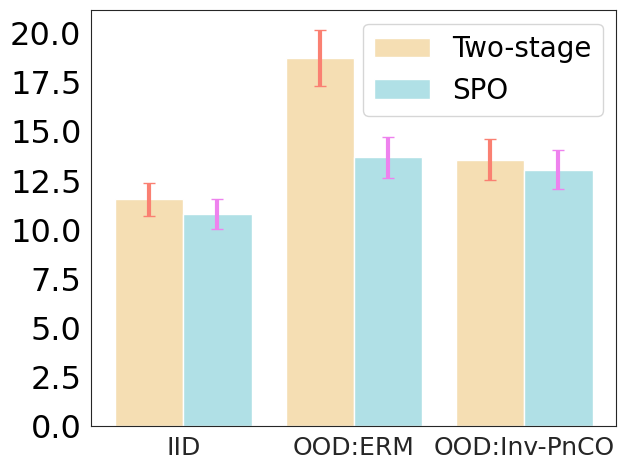

In [8]:

import matplotlib.pyplot as plt
import numpy as np
sns.set_style("white")

mse_names = \
    ["new-resnet_5e-4_0", "new-OOD_resnet_ERM_5e-4_0", "new-OOD_resnet_EERM_2-4.0-1e-5_1e-5"]
spo_names = \
    ["new-resnet_l1_1e-3_0", "new-OOD_resnet_ERM_5e-3_1e-4", "new-OOD_resnet_EERM_4-4.0-1e-4_1e-4"]

mse_results = [get_regret("mse", name, "shortestpath-warcraft-ood") for name in mse_names]
spo_results = [get_regret("spo", name, "shortestpath-warcraft-ood") for name in spo_names]

x=np.arange(3)
#数据集
y1 = [res.mean() for res in mse_results]
y2 = [res.mean() for res in spo_results]
#误差列表
std_err1= np.array([ np.std(res) for res in mse_results])/10
std_err2=  np.array([ np.std(res) for res in spo_results])/10
tick_label=["IID", "OOD:ERM", "OOD:Inv-PnCO"]
 
error_params1=dict(elinewidth=3,ecolor='salmon',capsize=4)#设置误差标记参数
error_params2=dict(elinewidth=3,ecolor='violet',capsize=4)#设置误差标记参数
#设置柱状图宽度
bar_width=0.4
#绘制柱状图，设置误差标记以及柱状图标签
plt.bar(x,y1,bar_width,color=['wheat']*len(x),yerr=std_err1,error_kw=error_params1,label='Two-stage')
plt.bar(x+bar_width,y2,bar_width,color=['powderblue']*len(x),yerr=std_err2,error_kw=error_params2,label='SPO')

plt.style.use('default')
plt.xticks(x+bar_width/2, tick_label, fontsize=18)#设置x轴的标签
plt.yticks(fontsize=23,color='#000000')
# plt.ylim(0,12.9)
#设置网格
# plt.grid(True,axis='y',ls=':',color='r',alpha=0.3)
#显示图例
plt.legend(fontsize=20, loc="upper right", ncol=1)
#显示图形
plt.tight_layout()
plt.savefig("/home/genghaoyu/OR/PTO/Rethink1.0/visual/figs/ood_figs/fig_sp.pdf")
plt.show()


## TSP figs

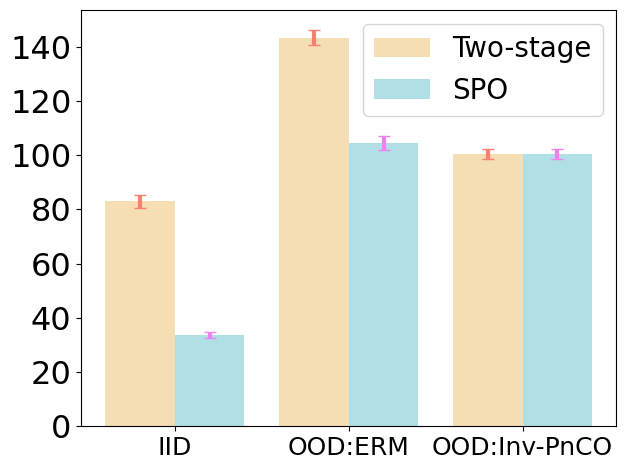

In [10]:

import matplotlib.pyplot as plt
import numpy as np


mse_names = \
    ["ver4-IID", "ver4-OOD-ERM",	"ver4-OOD-EERM-3envs_4.0_1e-3"]
spo_names = \
    ["ver4-IID", "ver4-OOD-ERM", "ver4-OOD-EERM-3envs_0.5_5e-3"]

mse_results = [get_regret("mse", name, "TSP-gen-ood") for name in mse_names]
spo_results = [get_regret("spo", name, "TSP-gen-ood") for name in spo_names]

x=np.arange(3)
#数据集
y1 = [res.mean() for res in mse_results]
y2 = [res.mean() for res in spo_results]
#误差列表
std_err1= np.array([ np.std(res) for res in mse_results])/10
std_err2=  np.array([ np.std(res) for res in spo_results])/10
tick_label=["IID", "OOD:ERM", "OOD:Inv-PnCO"]
 
error_params1=dict(elinewidth=3,ecolor='salmon',capsize=4)#设置误差标记参数
error_params2=dict(elinewidth=3,ecolor='violet',capsize=4)#设置误差标记参数
#设置柱状图宽度
bar_width=0.4
#绘制柱状图，设置误差标记以及柱状图标签
plt.bar(x,y1,bar_width,color=['wheat']*len(x),yerr=std_err1,error_kw=error_params1,label='Two-stage')
plt.bar(x+bar_width,y2,bar_width,color=['powderblue']*len(x),yerr=std_err2,error_kw=error_params2,label='SPO')

plt.style.use('default')
plt.xticks(x+bar_width/2, tick_label, fontsize=18)#设置x轴的标签
plt.yticks(fontsize=23,color='#000000')
# plt.ylim(0,12.9)
#设置网格
# plt.grid(True,axis='y',ls=':',color='r',alpha=0.3)
#显示图例
plt.legend(fontsize=20, loc="upper right", ncol=1)
#显示图形
plt.tight_layout()
plt.savefig("/home/genghaoyu/OR/PTO/Rethink1.0/visual/figs/ood_figs/fig_tsp.pdf")
plt.show()
